
=== RATA-RATA ===
Rata-rata usia     : 29.70 tahun
Rata-rata fare     : 34.69
Persentase survive : 40.62%
Rata-rata pclass   : 2.24

=== PERSENTASE PCLASS ===
pclass
3    49.719888
1    26.050420
2    24.229692
Name: proportion, dtype: float64

=== NILAI MAX & MIN ===
Usia Tertua   : 80.0
Usia Termuda  : 0.42
Fare Tertinggi: 512.3292
Fare Terendah : 0.0

=== OUTLIER FARE (IQR) ===
Jumlah outlier fare      : 94 record
Persentase outlier fare  : 13.17%

Contoh 5 outlier:
    survived  pclass                                      name     sex   age  \
23         0       1            Fortune, Mr. Charles Alexander    male  19.0   
26         0       1                   Meyer, Mr. Edgar Joseph    male  28.0   
38         1       1  Harper, Mrs. Henry Sleeper (Myna Haxtun)  female  49.0   
46         1       1                       Icard, Miss. Amelie  female  38.0   
47         0       1               Harris, Mr. Henry Birkhardt    male  45.0   

        fare  sibsp  parch  
23  263.0000   

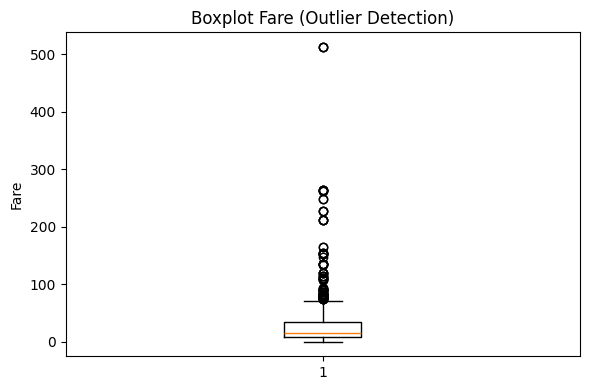

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. Load Dataset
# ==========================================
df = pd.read_csv("titanic.csv")


# ==========================================
# 2. Mean Values (termasuk persen)
# ==========================================
print("\n=== RATA-RATA ===")
mean_age = df['age'].mean()
mean_fare = df['fare'].mean()
mean_survived = df['survived'].mean() * 100   # jadi persen
mean_pclass = df['pclass'].mean()

print(f"Rata-rata usia     : {mean_age:.2f} tahun")
print(f"Rata-rata fare     : {mean_fare:.2f}")
print(f"Persentase survive : {mean_survived:.2f}%")
print(f"Rata-rata pclass   : {mean_pclass:.2f}")


# ==========================================
# 3. Persentase Pclass
# ==========================================
print("\n=== PERSENTASE PCLASS ===")
class_percent = df['pclass'].value_counts(normalize=True) * 100
print(class_percent)


# ==========================================
# 4. Max / Min age & fare
# ==========================================
print("\n=== NILAI MAX & MIN ===")
print(f"Usia Tertua   : {df['age'].max()}")
print(f"Usia Termuda  : {df['age'].min()}")
print(f"Fare Tertinggi: {df['fare'].max()}")
print(f"Fare Terendah : {df['fare'].min()}")


# ==========================================
# 5. Outlier Fare (IQR)
# ==========================================
print("\n=== OUTLIER FARE (IQR) ===")

Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

outliers = df[df['fare'] > upper]
percent_outliers = (len(outliers) / len(df)) * 100

print(f"Jumlah outlier fare      : {len(outliers)} record")
print(f"Persentase outlier fare  : {percent_outliers:.2f}%")
print("\nContoh 5 outlier:")
print(outliers.head())


# ==========================================
# 6. Visualisasi Outlier Fare
# ==========================================
plt.figure(figsize=(6,4))
plt.boxplot(df['fare'].dropna())
plt.title("Boxplot Fare (Outlier Detection)")
plt.ylabel("Fare")
plt.tight_layout()
plt.show()